<a href="https://colab.research.google.com/github/KP-365/Natural_Gas_Pricing/blob/main/storage_volatility_poc_Kayleb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Gas Storage → Volatility Proof of Concept

Quick test: does an OLS-residual-based uncertainty proxy correlate with realised
natural gas price volatility?

**Two modes:**
- **Demo mode** (default below): synthetic data shaped like real EIA/NOAA/Henry Hub
  values, runs immediately, no API key needed. Use this to confirm the pipeline
  works end-to-end.
- **Real mode**: set your free EIA API key below and flip `USE_REAL_DATA = True`.
  HDD/CDD come from NOAA's Climate Prediction Center (free, no key needed at all).

Get a free EIA key at: https://www.eia.gov/opendata/register.php


In [1]:
import re
import os
import numpy as np
import pandas as pd
from scipy import stats
import requests
import matplotlib.pyplot as plt

# --- Configuration ---
USE_REAL_DATA = True
MONTHS_BACK = 12               # how much history to use
EIA_API_KEY = "lCNrpiQugnNaUoJ1kOelcXsXCFt748mrv2l3yOpo"

CPC_HEATING_URL = "https://ftp.cpc.ncep.noaa.gov/htdocs/degree_days/weighted/legacy_files/heating/statesCONUS/{year}/weekly-{yyyymmdd}.txt"
CPC_COOLING_URL = "https://ftp.cpc.ncep.noaa.gov/htdocs/degree_days/weighted/legacy_files/cooling/statesCONUS/{year}/weekly-{yyyymmdd}.txt"

EIA_STORAGE_URL = "https://api.eia.gov/v2/natural-gas/stor/wkly/data/"
EIA_STORAGE_PARAMS = {
    "frequency": "weekly",
    "data[0]": "value",
    "start": "2025-01-01",
    "end": "2026-01-01",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "offset": 0,
    "length": 5000,
}

EIA_PRICE_URL = "https://api.eia.gov/v2/natural-gas/pri/fut/data/"
EIA_PRICE_PARAMS = {
    "frequency": "daily",
    "data[0]": "value",
    "start": "2025-01-01",
    "end": "2026-01-01",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "offset": 0,
    "length": 5000,
}


## 1. Data fetch functions (real EIA + NOAA CPC, and synthetic demo)

In [2]:
def fetch_eia_storage(api_key: str, start: str = None, end: str = None) -> pd.Series:
    """Pull weekly Lower-48 total working gas storage via EIA's v2 API.
    Filters down to the national total (duoarea == 'R48')."""
    params = dict(EIA_STORAGE_PARAMS)
    params["api_key"] = api_key
    if start:
        params["start"] = start
    if end:
        params["end"] = end
    resp = requests.get(EIA_STORAGE_URL, params=params, timeout=30)
    resp.raise_for_status()
    df = pd.DataFrame(resp.json()["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df = df[df["duoarea"] == "R48"]
    df = df.sort_values("period").set_index("period")
    return df["value"].astype(float)


def fetch_eia_price(api_key: str, start: str = None, end: str = None) -> pd.Series:
    """Pull daily Henry Hub spot price via EIA's v2 API."""
    params = dict(EIA_PRICE_PARAMS)
    params["api_key"] = api_key
    if start:
        params["start"] = start
    if end:
        params["end"] = end
    resp = requests.get(EIA_PRICE_URL, params=params, timeout=30)
    resp.raise_for_status()
    df = pd.DataFrame(resp.json()["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df = df[df["series"] == "RNGWHHD"]  # Henry Hub spot specifically
    df = df.sort_values("period").set_index("period")
    return df["value"].astype(float)


def fetch_cpc_national_degree_days(date: pd.Timestamp, kind: str = "heating") -> float:
    """Fetch NOAA CPC's free, no-key, population-weighted national weekly
    HDD or CDD total for the week ending on `date`."""
    url_tmpl = CPC_HEATING_URL if kind == "heating" else CPC_COOLING_URL
    url = url_tmpl.format(year=date.year, yyyymmdd=date.strftime("%Y%m%d"))
    resp = requests.get(url, timeout=20)
    resp.raise_for_status()
    match = re.search(r"POPULATION WEIGHTED\s+REGION.*?UNITED STATES\s+(\d+)", resp.text, re.S)
    if not match:
        raise ValueError(f"Could not parse national degree-day total from {url}")
    return float(match.group(1))


def get_real_hdd_cdd(weeks_index: pd.DatetimeIndex):
    hdd, cdd = [], []
    for d in weeks_index:
        try:
            hdd.append(fetch_cpc_national_degree_days(d, "heating"))
        except Exception:
            hdd.append(np.nan)
        try:
            cdd.append(fetch_cpc_national_degree_days(d, "cooling"))
        except Exception:
            cdd.append(np.nan)
    return np.array(hdd), np.array(cdd)


def fetch_eia_capacity(api_key: str) -> float:
    """Pull EIA's most recent published U.S. Lower-48 working gas capacity (Bcf).
    Falls back to a fixed approximate value (4300 Bcf) if the API call fails,
    since the capacity route's exact schema hasn't been verified against a live key."""
    try:
        params = {
            "api_key": api_key,
            "frequency": "annual",
            "data[0]": "value",
            "sort[0][column]": "period",
            "sort[0][direction]": "desc",
            "offset": 0,
            "length": 20,
        }
        resp = requests.get("https://api.eia.gov/v2/natural-gas/stor/cap/data/", params=params, timeout=30)
        resp.raise_for_status()
        df = pd.DataFrame(resp.json()["response"]["data"])
        df = df[df["duoarea"] == "R48"]
        if df.empty:
            raise ValueError("no R48 rows in capacity response")
        return float(df.sort_values("period")["value"].iloc[-1])
    except Exception as e:
        print(f"Capacity fetch failed ({e}); using fallback 4300 Bcf.")
        return 4300.0


def get_real_data(months_back: int, api_key: str):
    """Returns weekly storage CHANGE (not level), price, HDD, CDD, and
    storage-level-as-fraction-of-capacity, all aligned to the same index."""
    if not api_key:
        raise RuntimeError("Set EIA_API_KEY (env var or in the config cell) first.")
    end = pd.Timestamp.today()
    start = end - pd.DateOffset(months=months_back)
    start_str, end_str = start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")

    storage_level = fetch_eia_storage(api_key, start_str, end_str)
    price = fetch_eia_price(api_key, start_str, end_str)
    capacity = fetch_eia_capacity(api_key)

    storage_change = storage_level.diff().dropna()

    storage_fraction = (storage_level / capacity).shift(1).reindex(storage_change.index)

    hdd, cdd = get_real_hdd_cdd(storage_change.index)
    return storage_change, price, hdd, cdd, storage_fraction


def get_demo_data(weeks: int = 52, seed: int = 7, demo_capacity: float = 4300.0):
    """Synthetic data shaped like real seasonal storage/price behaviour --
    purely to demonstrate the pipeline mechanics before plugging in real data.
    Also derives a synthetic storage LEVEL (starting mid-range) so a
    storage-fraction-of-capacity predictor can be demonstrated, matching
    the real-data path."""
    rng = np.random.default_rng(seed)
    week_idx = pd.date_range("2026-01-16", periods=weeks, freq="W-FRI")

    hdd = np.clip(60 - np.arange(weeks) * 2 + rng.normal(0, 5, weeks), 0, None)
    cdd = np.clip(np.arange(weeks) * 2 - 10 + rng.normal(0, 5, weeks), 0, None)

    noise_scale = 5 + 0.15 * (hdd + cdd)
    net_change = 40 - 0.3 * hdd - 0.2 * cdd + rng.normal(0, noise_scale)
    storage_change = pd.Series(net_change, index=week_idx)

    # Synthetic level path: start near mid-capacity
    starting_level = demo_capacity * 0.45
    storage_level = pd.Series(starting_level + np.cumsum(net_change), index=week_idx)
    storage_fraction = (storage_level / demo_capacity).shift(1).fillna(storage_level.iloc[0] / demo_capacity)

    daily_idx = pd.date_range(week_idx.min(), periods=weeks * 7, freq="D")
    price = [3.50]
    week_of_day = np.repeat(np.arange(weeks), 7)[: len(daily_idx)]
    for i in range(1, len(daily_idx)):
        w = week_of_day[i]
        vol_today = 0.02 + 0.004 * abs(noise_scale[w] - noise_scale.mean())
        price.append(price[-1] + rng.normal(0, vol_today))
    price_series = pd.Series(price, index=daily_idx)

    return storage_change, price_series, hdd, cdd, storage_fraction


## 2. Load the data (real or demo)

In [3]:
weeks_from_months = int(MONTHS_BACK * 4.345)

if USE_REAL_DATA:
    storage, price, hdd, cdd, storage_fraction = get_real_data(MONTHS_BACK, EIA_API_KEY)
    print(f"Loaded {len(storage)} real weekly storage-change observations, {len(price)} price observations.")
else:
    print(f"Using DEMO data ({MONTHS_BACK} months, synthetic, no API key needed).")
    storage, price, hdd, cdd, storage_fraction = get_demo_data(weeks=weeks_from_months)

hdd = np.asarray(hdd)[-len(storage):]
cdd = np.asarray(cdd)[-len(storage):]
storage_fraction = pd.Series(storage_fraction).reindex(storage.index).ffill().bfill().values

storage.tail()

Capacity fetch failed (no R48 rows in capacity response); using fallback 4300 Bcf.
Loaded 50 real weekly storage-change observations, 241 price observations.


,value
period,
2026-06-19,76.0
2026-06-26,87.0
2026-07-03,61.0
2026-07-10,41.0
2026-07-17,32.0


## 3. Fit the OLS baseline

In [4]:

X = np.column_stack([np.ones(len(hdd)), hdd, cdd, storage_fraction])
y = storage.values

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
y_hat = X @ beta
residuals = y - y_hat

rmse = np.sqrt(np.mean(residuals**2))
print(f"Intercept: {beta[0]:.2f}   HDD coef: {beta[1]:.3f}   CDD coef: {beta[2]:.3f}   Storage-fraction coef: {beta[3]:.3f}")
print(f"RMSE: {rmse:.2f} Bcf")

Intercept: 216.82   HDD coef: -1.953   CDD coef: -2.257   Storage-fraction coef: -14.605
RMSE: 20.40 Bcf


## 4. Rolling residual-based uncertainty proxy

A quick stand-in for the real Bayesian/heteroscedastic interval width: rolling mean absolute residual over the last 6 weeks.

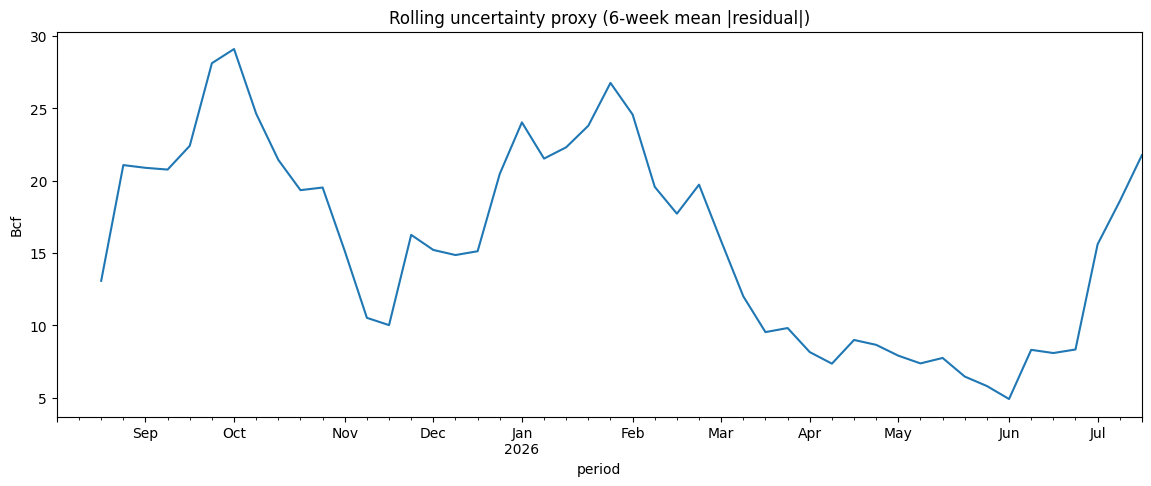

In [5]:
resid_series = pd.Series(residuals, index=storage.index)
rolling_uncertainty = resid_series.abs().rolling(6, min_periods=3).mean()
rolling_uncertainty.plot(title="Rolling uncertainty proxy (6-week mean |residual|)", figsize=(14, 5))
plt.ylabel("Bcf")
plt.show()

## 5. Realised price volatility following each week

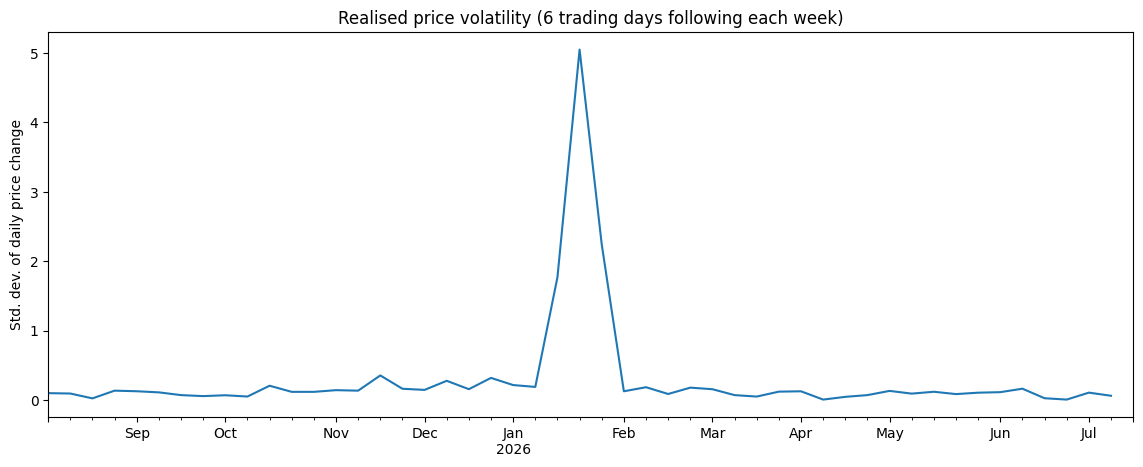

In [6]:
def realised_volatility(price: pd.Series, start, days: int = 6) -> float:
    """Std dev of daily price changes over `days` trading days following `start`."""
    window = price[(price.index > start) & (price.index <= start + pd.Timedelta(days=days))]
    if len(window) < 2:
        return np.nan
    return window.diff().dropna().std()


realised_vol = pd.Series({t: realised_volatility(price, t) for t in storage.index})
realised_vol.plot(title="Realised price volatility (6 trading days following each week)", figsize=(14, 5))
plt.ylabel("Std. dev. of daily price change")
plt.show()

## 6. Correlate: does predicted uncertainty precede realised volatility?

In [7]:
df = pd.DataFrame({
    "predicted_uncertainty": rolling_uncertainty,
    "realised_vol_next_6d": realised_vol,
}).dropna()

if len(df) < 2:
    print(f"Only {len(df)} valid (non-NaN) paired observations -- not enough to correlate.")
    print("Check that `price` has daily (not weekly) granularity: len(price) should be roughly 7x len(storage).")
    corr, pval = np.nan, np.nan
else:
    corr, pval = stats.pearsonr(df["predicted_uncertainty"], df["realised_vol_next_6d"])
    print(f"Pearson correlation: {corr:.3f}   (p-value: {pval:.4f})")
    if corr > 0.2 and pval < 0.1:
        print("-> Positive signal: weeks with higher predicted uncertainty tend to precede higher realised volatility.")
    else:
        print("-> No strong signal in this sample (expected on short windows or synthetic demo data).")

df

Pearson correlation: 0.309   (p-value: 0.0348)
-> Positive signal: weeks with higher predicted uncertainty tend to precede higher realised volatility.


,predicted_uncertainty,realised_vol_next_6d
2025-08-22,13.073227,0.023094
2025-08-29,21.072593,0.134350
2025-09-05,20.884140,0.125831
2025-09-12,20.762489,0.109697
2025-09-19,22.405130,0.070238
2025-09-26,28.116636,0.055678
2025-10-03,29.097046,0.068069
2025-10-10,24.625273,0.049497
2025-10-17,21.432680,0.205264
2025-10-24,19.339112,0.117189


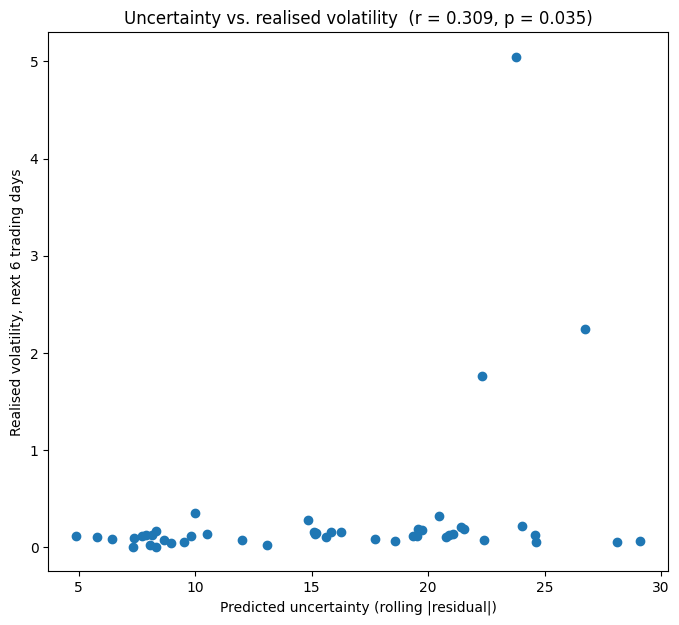

In [8]:
if len(df) >= 2:
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(df["predicted_uncertainty"], df["realised_vol_next_6d"])
    ax.set_xlabel("Predicted uncertainty (rolling |residual|)")
    ax.set_ylabel("Realised volatility, next 6 trading days")
    ax.set_title(f"Uncertainty vs. realised volatility  (r = {corr:.3f}, p = {pval:.3f})")
    plt.show()